# Daily-Return LSTM — Walk-Forward Notebook  
 *AAPL example – 20 % validation inside each fold, final 200-day hold-out*

 **Contents**
 1. Imports & helper classes  
 2. Data fetch → CSV cache  
 3. Indicator engineering & raw visualisation  
 4. Window builder + Dataset + train/val/test split chart  
 5. Walk-forward training loop with early-stopping  
 6. Fold metrics + prediction vs actual plots  
 7. Save best model, scalers & feature order  
 8. Reload demo from a fresh Python session

In [15]:
import os
import requests
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime, timedelta
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections.abc import Sized
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pandas.tseries.offsets import QuarterEnd
from typing import Any


WINDOW_SIZE  = 30          # sliding window length
EPOCHS       = 60
BATCH        = 32
HIDDEN_DIM   = 100
DROPOUT      = 0.5
LR           = 1e-3
WD           = 5e-4
PATIENCE     = 8
N_SPLITS     = 5
TEST_SIZE    = 100         
TARGET       = "Return_1D"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [16]:
API_KEY = "JcmfjzcBwo5HGSiM5Yib7ylfG2PmSNzc"
TICKER  = "AMD"

def fetch_all_history(ticker: str, api_key: str) -> pd.DataFrame:
    all_chunks = []
    to_date = datetime.today().date()
    chunk_size = 1500

    while True:
        from_date = to_date - timedelta(days=int(chunk_size*1.5))
        url = (
            f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}"
            f"?from={from_date:%Y-%m-%d}&to={to_date:%Y-%m-%d}"
            f"&apikey={api_key}"
        )
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json().get("historical", [])
        if not data:
            break

        df_chunk = pd.DataFrame(data)[["date","open","high","low","close","volume"]]
        df_chunk["date"] = pd.to_datetime(df_chunk["date"])
        all_chunks.append(df_chunk)

        earliest = df_chunk["date"].min().date()
        if (to_date - earliest).days < 2:
            break
        to_date = earliest - timedelta(days=1)

    df = pd.concat(all_chunks, ignore_index=True)
    df = df.drop_duplicates(subset="date").sort_values("date").reset_index(drop=True)

    df["Return_3D"]     = df["close"].pct_change(periods=3).shift(-3)
    df["Return_1D"]     = df["close"].pct_change()
    df["Volatility_3D"] = df["Return_1D"].rolling(window=3).std()

    return df.dropna(subset=["Return_3D","Volatility_3D"]).reset_index(drop=True)


if __name__ == "__main__":
    # fetch and assemble the full history
    df = fetch_all_history(TICKER, API_KEY)

    # ensure the output folder exists
    os.makedirs("data", exist_ok=True)

    # write the CSV into data/{TICKER}_full_history.csv
    out_path = os.path.join("data", f"{TICKER}_full_history.csv")
    df.to_csv(
        out_path,
        index=False,
        columns=[
            "date","open","high","low","close","volume",
            "Return_3D","Volatility_3D"
        ],
        date_format="%Y-%m-%d"
    )

    print(df.head(10)[
        ["date","open","high","low","close","volume","Return_3D","Volatility_3D"]
    ].to_csv(index=False))

date,open,high,low,close,volume,Return_3D,Volatility_3D
1980-03-20,3.04,3.06,3.01,3.01,159600,-0.1362126245847175,0.021149319398710734
1980-03-21,3.01,3.02,2.91,2.92,130800,-0.1609589041095889,0.016718141069111882
1980-03-24,2.92,2.92,2.64,2.67,436800,-0.10861423220973787,0.039249891874560044
1980-03-25,2.67,2.75,2.55,2.6,645600,-0.023076923076923106,0.03328191669009583
1980-03-26,2.6,2.6,2.43,2.45,466800,0.03673469387755102,0.02971728964059351
1980-03-27,2.45,2.45,2.24,2.38,1129200,0.1512605042016808,0.017532106126183347
1980-03-28,2.38,2.58,2.38,2.54,666000,0.03543307086614167,0.0653581794521977
1980-03-31,2.54,2.58,2.52,2.54,430800,0.03937007874015741,0.049181804490058524
1980-04-01,2.54,2.77,2.54,2.74,492000,-0.07299270072992703,0.042528466057929766
1980-04-02,2.74,2.74,2.61,2.63,283200,-0.01520912547528519,0.06047813311876296



In [17]:

df = pd.read_csv("data/AAPL_full_history.csv", parse_dates=["date"])
df = df.rename(columns={
    "open": "Open", "high": "High", "low": "Low",
    "close": "Close", "volume": "Volume"
})
df = df.set_index("date")


def compute_indicators(df):
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    roll_up  = gain.ewm(span=14).mean()
    roll_down= loss.ewm(span=14).mean()
    rs  = roll_up / roll_down
    df["RSI"] = 100 - 100 / (1 + rs)

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    signal= macd.ewm(span=9, adjust=False).mean()
    df["MACD"]        = macd
    df["MACD_Signal"] = signal
    df["MACD_Hist"]   = macd - signal

    sma  = df["Close"].rolling(20).mean()
    std  = df["Close"].rolling(20).std()
    df["BB_Mid"]   = sma
    df["BB_Upper"] = sma + 2*std
    df["BB_Lower"] = sma - 2*std

    df["Return_1D"] = df["Close"].pct_change().shift(-1)
    df.dropna(inplace=True)
    return df

df = compute_indicators(df)
df["lag1_ret"] = df["Return_1D"].shift(1)
df.dropna(inplace=True)

feature_cols = ["lag1_ret"] + [c for c in df.columns if c not in (TARGET, "lag1_ret")]
print("Features:", feature_cols)


Features: ['lag1_ret', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return_3D', 'Volatility_3D', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower', 'Return_1D']


In [18]:
# ---------------------------------------------------------------
#  prepare_data_quarterly_minmax
# ---------------------------------------------------------------
def prepare_data_quarterly_minmax(df, feature_cols, target_col, window_size):
    df = df.copy()
    df["Quarter"] = df.index.to_period("Q")

    scaled_chunks, scalers = [], {}
    for q, g in df.groupby("Quarter"):
        if len(g) < window_size:           # skip tiny quarters
            continue
        mms = MinMaxScaler()
        chunk = g[feature_cols + [target_col]]
        scaled = mms.fit_transform(chunk)
        scaled_chunks.append(
            pd.DataFrame(scaled, index=g.index,
                         columns=feature_cols + [target_col])
        )
        scalers[str(q)] = mms

    df_scaled = pd.concat(scaled_chunks).sort_index()
    df_scaled.dropna(inplace=True)

    X, y = [], []
    data   = df_scaled[feature_cols].values
    target = df_scaled[target_col].values
    for i in range(window_size, len(df_scaled)):
        X.append(data[i-window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y), scalers, df_scaled

X_all, y_all, scalers_q, df_scaled = prepare_data_quarterly_minmax(
    df, feature_cols, TARGET, WINDOW_SIZE
)
print("Windows:", X_all.shape)


KeyError: "['Return_5D'] not in index"

In [5]:
class StockDataset(Dataset):
    def __init__(self, X: Any, y: Any):
        self.X, self.y = X, y
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            dropout=dropout, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0),
                         self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.count, self.stop = None, 0, False
    def __call__(self, val):
        if self.best is None or self.best - val > self.min_delta:
            self.best, self.count = val, 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True

def build_windows(arr_x, arr_y, win):
    X, y = [], []
    for i in range(win, len(arr_x)):
        X.append(arr_x[i-win:i]); y.append(arr_y[i])
    return np.array(X), np.array(y)


In [ ]:
def walk_forward_minmax_verbose(
        X, y,
        window        = WINDOW_SIZE,
        n_splits      = N_SPLITS,
        test_size     = TEST_SIZE,
        hidden        = HIDDEN_DIM,
        dropout       = DROPOUT,
        lr            = LR,
        wd            = WD,
        epochs        = EPOCHS,
        patience      = PATIENCE,
        batch         = BATCH,
        device        = device
    ):
    metrics = []
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

    for fold, (tr, vl) in enumerate(tscv.split(X), 1):
        net  = LSTMModel(len(feature_cols), hidden_dim=hidden,
                         dropout=dropout).to(device)
        opt  = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
        stop = EarlyStopping(patience)

        tr_loader = DataLoader(StockDataset(X[tr], y[tr]),
                               batch_size=batch, shuffle=True)
        vl_loader = DataLoader(StockDataset(X[vl], y[vl]),
                               batch_size=batch)

        # ---------- training ----------
        for ep in range(1, epochs+1):
            # train
            net.train(); running = 0.0
            for xb, yb in tr_loader:
                xb, yb = xb.float().to(device), yb.float().to(device)
                opt.zero_grad()
                loss = nn.MSELoss()(net(xb).squeeze(-1), yb)
                loss.backward(); opt.step()
                running += loss.item() * xb.size(0)
            train_loss = running / len(tr_loader.dataset)# type: ignore

            # validation
            net.eval(); vloss = 0.0
            with torch.no_grad():
                for xb, yb in vl_loader:
                    vloss += nn.MSELoss()(net(xb.float().to(device)).squeeze(-1),
                                          yb.float().to(device)).item()*xb.size(0)
            vloss /= len(vl_loader.dataset)# type: ignore

            print(f"Fold {fold} | Epoch {ep:02d}/{epochs} "
                  f"Train {train_loss:.6f}  Val {vloss:.6f}")

            stop(vloss)
            if stop.stop:
                print(f"Early stop at epoch {ep} on fold {fold}\n")
                break

        # ---------- predict validation ----------
        net.eval(); preds=[]
        with torch.no_grad():
            for xb,_ in vl_loader:
                preds.extend(net(xb.float().to(device)).squeeze(-1).cpu().numpy())
        preds = np.array(preds); acts = y[vl]

        r2  = r2_score(acts, preds)
        mse = mean_squared_error(acts, preds)
        mae = mean_absolute_error(acts, preds)
        print(f"Fold {fold} FINAL  R² {r2:.3f}  MSE {mse:.6f}  MAE {mae:.6f}\n")

        metrics.append({
            "fold": fold, "r2": r2, "mse": mse, "mae": mae,
            "model_state": net.state_dict(),
            "hidden_dim": hidden, "num_layers": 2,
            "window": window
        })

    df_metrics = pd.DataFrame(metrics)
    print("=== CV mean ===")
    print(df_metrics[["r2","mse","mae"]].mean())
    return df_metrics
wfv = walk_forward_minmax_verbose(X_all, y_all)


Fold 1 | Epoch 01/60 Train 0.045871  Val 0.048281
Fold 1 | Epoch 02/60 Train 0.031498  Val 0.040390
Fold 1 | Epoch 03/60 Train 0.026814  Val 0.037853
Fold 1 | Epoch 04/60 Train 0.025085  Val 0.036243
Fold 1 | Epoch 05/60 Train 0.023905  Val 0.035538
Fold 1 | Epoch 06/60 Train 0.023347  Val 0.034769
Fold 1 | Epoch 07/60 Train 0.023007  Val 0.033954
Fold 1 | Epoch 08/60 Train 0.022605  Val 0.034575
Fold 1 | Epoch 09/60 Train 0.022362  Val 0.032440
Fold 1 | Epoch 10/60 Train 0.022016  Val 0.034064
Fold 1 | Epoch 11/60 Train 0.021179  Val 0.031712
Fold 1 | Epoch 12/60 Train 0.020448  Val 0.029367
Fold 1 | Epoch 13/60 Train 0.017202  Val 0.015732
Fold 1 | Epoch 14/60 Train 0.009654  Val 0.010178
Fold 1 | Epoch 15/60 Train 0.008179  Val 0.009266
Fold 1 | Epoch 16/60 Train 0.007867  Val 0.007420
Fold 1 | Epoch 17/60 Train 0.007466  Val 0.008264
Fold 1 | Epoch 18/60 Train 0.007243  Val 0.008693
Fold 1 | Epoch 19/60 Train 0.006968  Val 0.007503
Fold 1 | Epoch 20/60 Train 0.007019  Val 0.007109



Hold-out R² 0.881


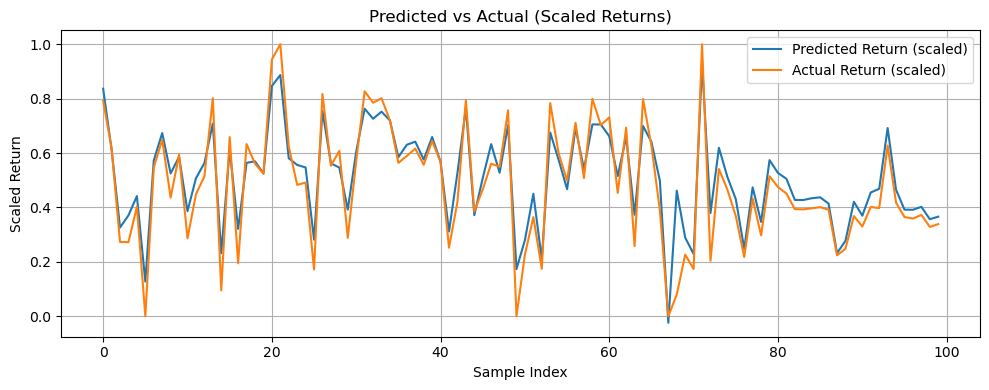

In [7]:
best_row = wfv.iloc[wfv["r2"].idxmax()] # type: ignore
WIN      = int(best_row["window"])

best_model = LSTMModel(len(feature_cols),
                       hidden_dim=int(best_row["hidden_dim"]),
                       dropout=DROPOUT).to(device)
best_model.load_state_dict(best_row["model_state"])
best_model.eval()

# ---- hold-out slice
X_hold = X_all[-TEST_SIZE:]
y_hold = y_all[-TEST_SIZE:]

with torch.no_grad():
    preds_hold = best_model(torch.tensor(X_hold).float().to(device)).cpu().numpy().ravel()

print(f"\nHold-out R² {r2_score(y_hold, preds_hold):.3f}")

# Plot Predicted vs Actual for Holdout Set
df_result = pd.DataFrame({
    "Predicted Return (scaled)": preds_hold,
    "Actual Return (scaled)": y_hold})

df_result.plot(figsize=(10, 4), title="Predicted vs Actual (Scaled Returns)")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
torch.save({
    "model_state":  best_row["model_state"],
    "hidden_dim":   int(best_row["hidden_dim"]),
    "num_layers":   2,
    "feature_order":feature_cols,
    "window":       WIN
}, "lstm_best.pth")
print("saved lstm_best.pth")


saved lstm_best.pth


7-day forecast (scaled): [0.3661 0.2936 0.3998 0.3823 0.3602 0.3965 0.3882]
7-day forecast (% returns): [-0.2499 -2.0301  0.5781  0.1488 -0.3938  0.4976  0.295 ]


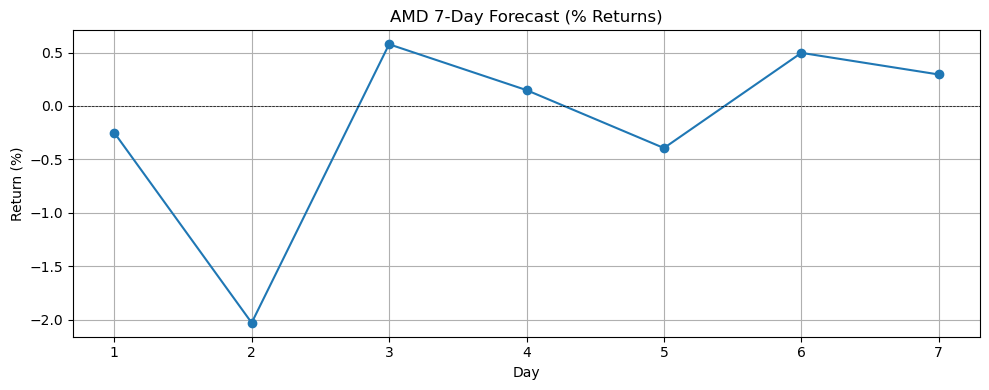

In [14]:
forecastDays = 7

def forecast_future_scaled(net, last_win_scaled, horizon):
    """
    Generate `horizon` future predictions in scaled space.
    """
    win   = last_win_scaled.copy()
    preds = []
    for _ in range(horizon):
        p = net(torch.tensor(win)
                   .float()
                   .unsqueeze(0)
                   .to(device)
               ).item()
        preds.append(p)
        new_row    = win[-1].copy()
        new_row[-1] = p
        win         = np.vstack([win[1:], new_row])
    return np.array(preds)

last_window_scaled = X_all[-1]

forecast_scaled = forecast_future_scaled(best_model, last_window_scaled, forecastDays)
print(f"{forecastDays}-day forecast (scaled):", np.round(forecast_scaled, 4))

q_last        = str(df_scaled.index[-1].to_period("Q"))
mms           = scalers_q[q_last]
scale, minv   = mms.data_max_[-1] - mms.data_min_[-1], mms.data_min_[-1]
forecast_raw  = forecast_scaled * scale + minv
forecast_pct  = forecast_raw * 100
print(f"{forecastDays}-day forecast (% returns):", np.round(forecast_pct, 4))

days = np.arange(1, forecastDays + 1)

plt.figure(figsize=(10, 4))
plt.plot(days, forecast_pct, marker='o', linestyle='-')
plt.title(f"{TICKER} {forecastDays}-Day Forecast (% Returns)")
plt.xlabel("Day")
plt.ylabel("Return (%)")
plt.xticks(days)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()
